In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

from concurrent.futures import ThreadPoolExecutor
import os

import numpy as np
import scipy.linalg as la
import matplotlib.pyplot as plt

from scripts.constants import PI, s2  # type: ignore
from scripts.utils import is_hermitian

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

In [2]:
X, Y = 10,10
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 1e-8
U0 = 2 * t
U = U0 * np.ones(lattice.X)
V0 = 1.5 * t 
V = V0 * np.ones(lattice.X)
V_prime = V
H = Hamiltonian(t, mu, lattice, 
                U=U, V_prime=None, V=None, F0_init=0.1)#,
                # F_init=[0.1, -0.1, 0.1j, -0.1j])

In [3]:
print(is_hermitian(H.build_H_kindep()))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_k(PI/3)))

True
True
True


In [4]:
print(H.lattice.pbc_x)

True


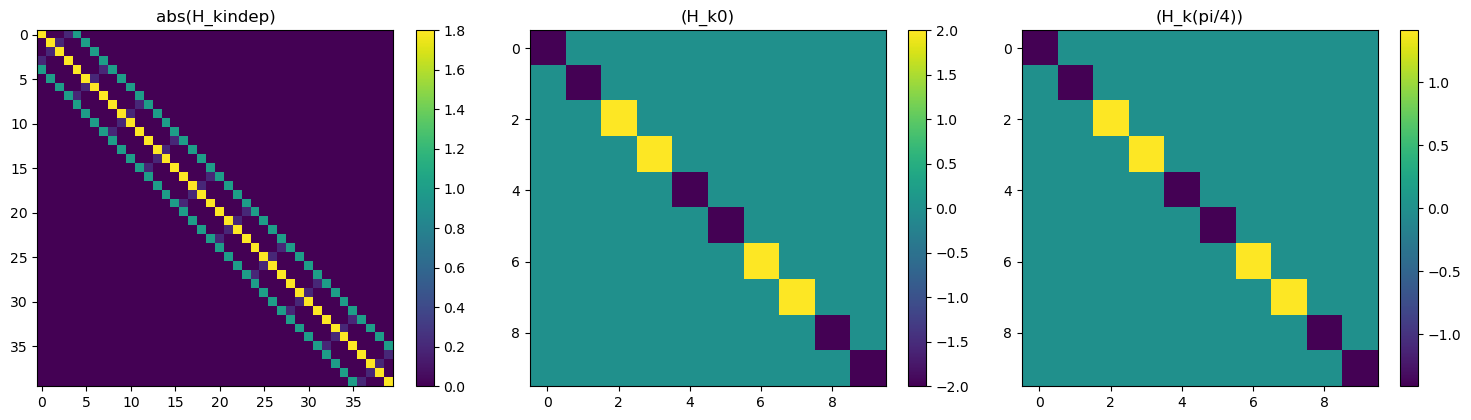

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

im0 = axs[0].imshow(np.abs(H.build_H_kindep()))
axs[0].set_title("abs(H_kindep)")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(np.real(H.build_H_k0())[0:10, 0:10])
axs[1].set_title("(H_k0)")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(np.real(H.build_H_k(PI/4))[0:10, 0:10])
axs[2].set_title("(H_k(pi/4))")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()


In [6]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, verbose=True, temperature=T)

F0:
Absolute error: 0.26675000164215346
Relative error: 2.6675000163948592
Average old: (0.1+0j)
Average: (0.1837970484257381+0j)
F_xplus:
Absolute error: 0.1725997786946759
Relative error: 172599778694.6759
Average old: 0j
Average: (-0.057254692712379936+0j)
F_xmin:
Absolute error: 0.17259977869467605
Relative error: 172599778694.67603
Average old: 0j
Average: (-0.05725469271237998+0j)
F_yplus:
Absolute error: 0.1593843612807444
Relative error: 159384361280.7444
Average old: 0j
Average: (-0.04833340906475739-9.959047475582853e-17j)
F_ymin:
Absolute error: 0.1593843612807444
Relative error: 159384361280.7444
Average old: 0j
Average: (-0.04833340906475739+9.959047475582853e-17j)
Fuu_xplus:
Absolute error: 3.8663600636288194e-17
Relative error: 3.8663600636288196e-05
Average old: 0j
Average: (1.6062238721397335e-18+0j)
Fuu_xmin:
Absolute error: 3.1421476521831096e-17
Relative error: 3.14214765218311e-05
Average old: 0j
Average: (-7.462173212201201e-18+0j)
Fuu_yplus:
Absolute error: 7.177

In [7]:
F_yplus = H.F_yplus
F_ymin = H.F_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.F_xplus
F_xmin[1:]  = H.F_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

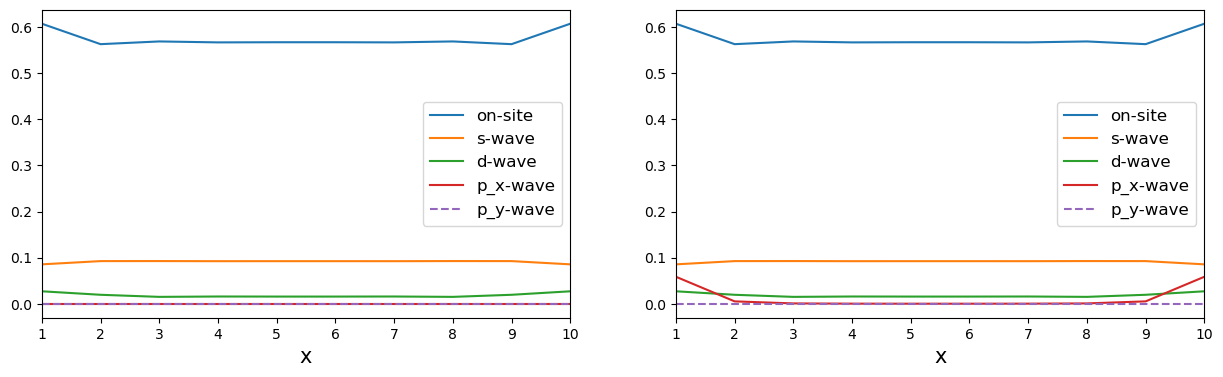

In [8]:
x = np.arange(1, X + 1)

fig, axs = plt.subplots(1, 2, figsize=(15, 4))

axs[0].plot(x, np.abs(F0), label="on-site")
axs[0].plot(x, np.abs(F_swave), label="s-wave")
axs[0].plot(x, np.abs(F_dwave), label="d-wave")
axs[0].plot(x, np.abs(F_px), label="p_x-wave")
axs[0].plot(x, np.abs(F_py), "--", label="p_y-wave")
axs[0].set_xlabel("x", fontsize=15)
axs[0].set_xlim(1, X)
axs[0].legend(fontsize=12, loc="best")

axs[1].plot(x, np.abs(F0), label="on-site")
axs[1].plot(x, np.abs(F_swave2), label="s-wave")
axs[1].plot(x, np.abs(F_dwave2), label="d-wave")
axs[1].plot(x, np.abs(F_px2), label="p_x-wave")
axs[1].plot(x, np.abs(F_py2), "--", label="p_y-wave")
axs[1].set_xlabel("x", fontsize=15)
axs[1].set_xlim(1, X)
axs[1].legend(fontsize=12, loc="best")

plt.show()

In [ ]:
X, Y = 10, 50
lattice = Lattice(X, Y)

t = 1
mu = 1.8 * t * np.ones(lattice.X)
T = 0

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j])

In [46]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=200, verbose=True, temperature=T)


F0:
Absolute error: 8.863995053448351e-16
Relative error: 0.000886399505344835
Average old: 0j
Average: (1.892994224914069e-16+0j)
F_xplus:
Absolute error: 0.2420559955586241
Relative error: 2.4205599555620347
Average old: (0.09999999999999999+0j)
Average: (0.17940495214971064+0j)
F_xmin:
Absolute error: 0.24205599555862384
Relative error: 2.4205599556104436
Average old: (-0.09999999999999999+0j)
Average: (-0.17940495214971056+0j)
F_yplus:
Absolute error: 0.344534186332796
Relative error: 3.4453418633279598
Average old: 0.1j
Average: (1.4173883421120247e-17+0.20799663549155256j)
F_ymin:
Absolute error: 0.344534186332796
Relative error: 3.4453418633279598
Average old: -0.1j
Average: (1.4173883421120247e-17-0.20799663549155256j)
Fuu_xplus:
Absolute error: 4.457047403590512e-17
Relative error: 4.4570474035905115e-05
Average old: 0j
Average: (-5.6039556265317336e-18+0j)
Fuu_xmin:
Absolute error: 5.0982266692343495e-17
Relative error: 5.09822666923435e-05
Average old: 0j
Average: (9.1901784

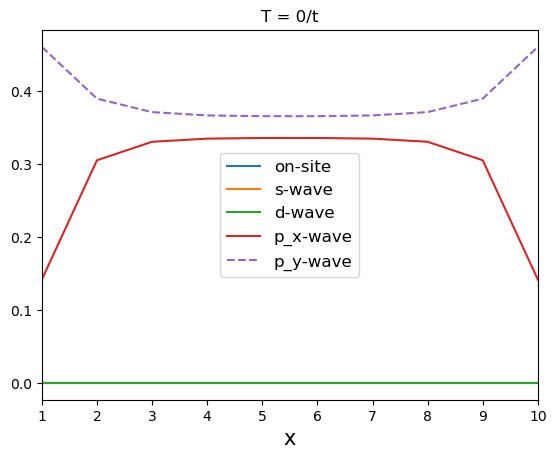

In [47]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

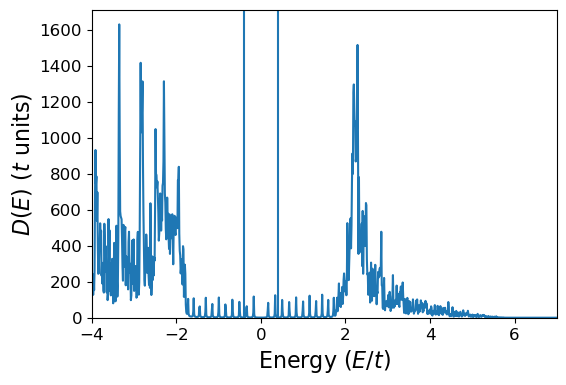

In [48]:
energies = np.linspace(-4,7,1000) 
dos_values = H.dos(energies, eta=0.0051)
plt.figure(figsize=(6,4))
plt.plot(energies, dos_values)
plt.ylim(0, None)
plt.xlim(-4,7)
plt.xlabel(r'Energy ($E/t$)', fontsize=16)
plt.ylabel(r'$D(E)$ ($t$ units)', fontsize=16)
plt.axvline(-0.2 * 2)
plt.axvline(+0.2 * 2)

# plt.text(2., 0.6, "(a)",fontsize=18, fontweight='bold', va='top', ha='left')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

In [13]:
free1 = H.free
free2 = H.free_energy()

print(free1)
print(free2)

-2346.6838675721187
-51.967980630639275


In [14]:
X, Y = 25, 50
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 0.5 * t * np.ones(lattice.X)
T = 1e-8

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 2 * t 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1 , -0.1])

In [15]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=1000,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.05366825448500668
Relative error: 53668254485.00668
Average old: 0j
Average: (-0.00135650454998115+0j)
F_xplus:
Absolute error: 0.5779060380012832
Relative error: 5.77906037995504
Average old: (0.09999999999999999+0j)
Average: (0.21727968576096193+0j)
F_xmin:
Absolute error: 0.5779060380012834
Relative error: 5.779060379955043
Average old: (0.09999999999999999+0j)
Average: (0.21727968576096202+0j)
F_yplus:
Absolute error: 0.5606407181312667
Relative error: 5.6064071813687315
Average old: (-0.1+0j)
Average: (-0.21194873786550011-1.468200561127731e-17j)
F_ymin:
Absolute error: 0.5606407181312667
Relative error: 5.6064071813687315
Average old: (-0.1+0j)
Average: (-0.21194873786550011+1.468200561127731e-17j)
Fuu_xplus:
Absolute error: 5.779731488513966e-17
Relative error: 5.779731488513965e-05
Average old: 0j
Average: (4.011659805373135e-18+0j)
Fuu_xmin:
Absolute error: 5.992969647866522e-17
Relative error: 5.992969647866523e-05
Average old: 0j
Average: (5.01905702718

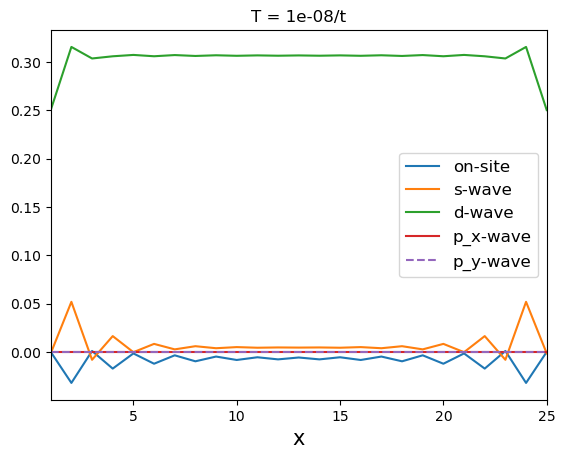

In [16]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
plt.plot(x, np.real(F0), label="on-site")
plt.plot(x, np.real(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.imag(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")

In [17]:
X, Y = 25, 50
lattice = Lattice(X, Y, pbc_x=True)

t = 1
mu = 0.9 * t * np.ones(lattice.X)
T = 0.1

U0 = 2 * t
U = U0 * np.ones(lattice.X)

V0 = 2 * t 
V = V0 * np.ones(lattice.X)

V_prime = V

H = Hamiltonian(t, mu, lattice, 
                U=None, V_prime=None, V=V,
                F_init=[0.1, 0.1, -0.1+0.1, -0.1-0.1])

In [18]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, rtol=0.01, maxiter=100, atol =1e-4,
                                      verbose=True, temperature=T)

F0:
Absolute error: 0.07685546898443803
Relative error: 76855468984.43803
Average old: 0j
Average: (0.005314470837527948-1.5069195891115325e-17j)
F_xplus:
Absolute error: 0.39795015986956805
Relative error: 3.979501598655885
Average old: (0.09999999999999999+0j)
Average: (0.18078704493455217+2.750904385288739e-17j)
F_xmin:
Absolute error: 0.3979501598695678
Relative error: 3.979501598655882
Average old: (0.09999999999999999+0j)
Average: (0.18078704493455214-7.799592316043892e-18j)
F_yplus:
Absolute error: 0.05916464153755573
Relative error: 59164641537.55574
Average old: 0j
Average: (-0.007956160940429833+2.7717758643852618e-17j)
F_ymin:
Absolute error: 0.7620501609351604
Relative error: 3.8102508046948533
Average old: (-0.2+0j)
Average: (-0.35228697530633-5.9729131363095444e-18j)
Fuu_xplus:
Absolute error: 1.0602075269241155e-16
Relative error: 0.00010602075269241155
Average old: 0j
Average: (-3.567272889948613e-18+1.3430719694858435e-18j)
Fuu_xmin:
Absolute error: 1.0089590682500707e

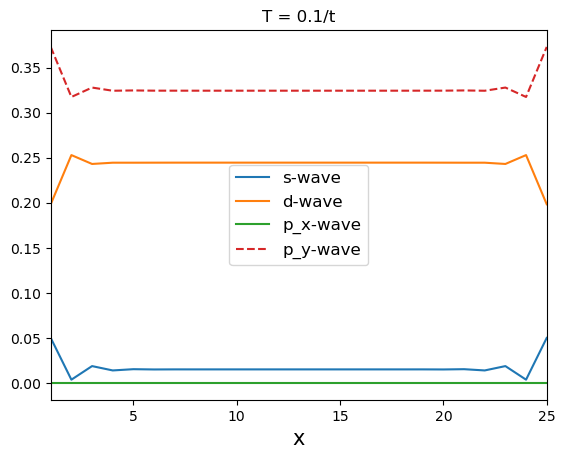

In [19]:
x = np.arange(1, X + 1)
F0 = H.F0
plt.title(f"T = {T}/t")
# plt.plot(x, np.abs(F0), label="on-site")
plt.plot(x, np.abs(F_swave), label="s-wave")
plt.plot(x, np.real(F_dwave), label="d-wave")
plt.plot(x, np.real(F_px), label="p_x-wave")
plt.plot(x, np.real(F_py), "--", label="p_y-wave")
plt.xlabel("x", fontsize=15)
plt.xlim(1, X)
plt.legend(fontsize=12, loc="best")